# 🛍️ Shopping Mall Customer Segmentation
## Member 1 — K-Means Clustering

---
### 📌 How K-Means Works (Simple Explanation)

Think of it like sorting coloured balls into buckets:
1. You decide how many buckets (K) you want
2. You randomly place K 'centre points' in the data
3. Every customer joins the nearest centre
4. Each centre moves to the middle of its group
5. Repeat steps 3–4 until nothing changes

**The challenge:** You must decide K (number of groups) upfront.
→ We use the **Elbow Method** to find the best K.

> ⚠️ Run `step0_eda_preprocessing.ipynb` first!

---
## Step 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    v_measure_score, homogeneity_score, completeness_score
)
from joblib import dump, load
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Load preprocessed data
X_scaled = np.load('data/X_scaled.npy')
df_clean = pd.read_csv('data/data_preprocessed.csv')
df       = pd.read_csv('data/Shopping_Mall_Customer_Segmentation_Data_.csv')

# Re-fit scaler (needed for predicting new customers later)
scaler = StandardScaler()
scaler.fit(df_clean)

print('✅ Data loaded')
print(f'   Customers : {len(df_clean):,}')
print(f'   Features  : {X_scaled.shape[1]} (Age, Gender, Annual Income, Spending Score)')

✅ Data loaded
   Customers : 15,079
   Features  : 4 (Age, Gender, Annual Income, Spending Score)


---
## Step 2: Find Optimal K — Elbow Method + Silhouette Score

### 📌 Why do we need to find K?
K-Means needs you to say 'I want X groups' upfront.
But how do we know the right number?

**Elbow Method:** We try K=2 to K=10 and measure Inertia (how compact the clusters are).
- Lower inertia = clusters are tighter = better
- But more clusters always means lower inertia (if K=15079, each customer is their own cluster!)
- We find the **elbow point** — where adding more K stops helping much

**Silhouette Score:** Also measures cluster quality (0 to 1, higher = better).
We pick the K with the highest silhouette score.

In [2]:
inertias         = []
silhouette_scores = []
K_range          = range(2, 11)

print('Testing K values...')
for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f'  K={k:2d} | Inertia={km.inertia_:,.0f} | Silhouette={sil:.4f}')

# Automatically find best K
best_k_sil = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f'\n✅ Best K by Silhouette Score: {best_k_sil}')

Testing K values...
  K= 2 | Inertia=45,236 | Silhouette=0.2635
  K= 3 | Inertia=39,501 | Silhouette=0.2225
  K= 4 | Inertia=33,832 | Silhouette=0.2401
  K= 5 | Inertia=30,429 | Silhouette=0.2331
  K= 6 | Inertia=26,912 | Silhouette=0.2383
  K= 7 | Inertia=24,213 | Silhouette=0.2475
  K= 8 | Inertia=21,418 | Silhouette=0.2638
  K= 9 | Inertia=19,694 | Silhouette=0.2668
  K=10 | Inertia=17,935 | Silhouette=0.2683

✅ Best K by Silhouette Score: 10


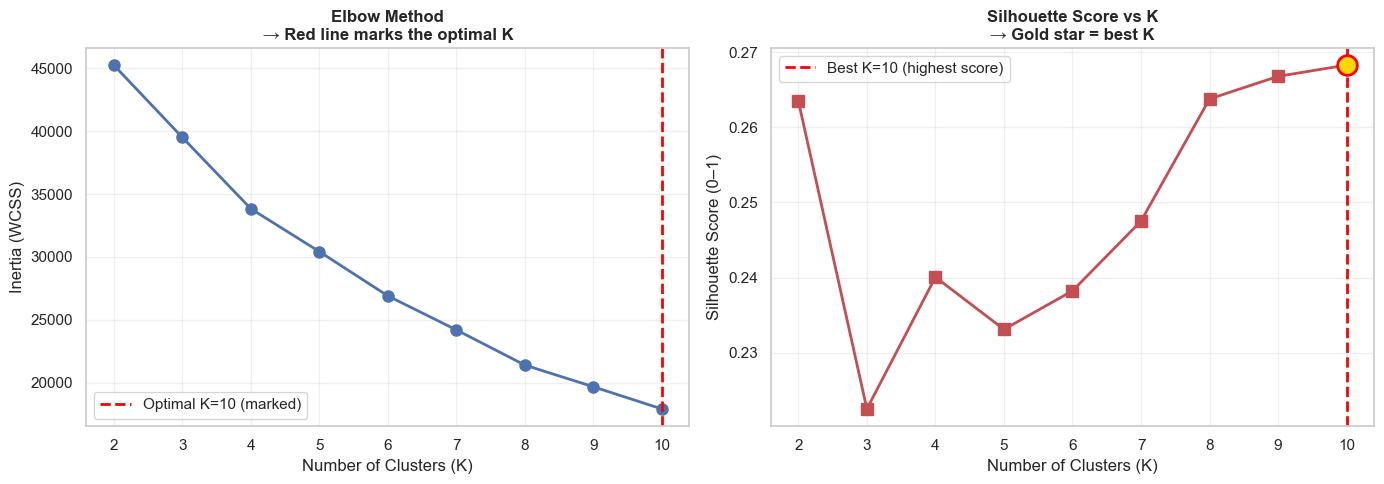

📊 Result: Optimal K = 10
   → We will train K-Means with K=10 clusters.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=best_k_sil, color='red', linestyle='--', linewidth=2,
                label=f'Optimal K={best_k_sil} (marked)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method\n→ Red line marks the optimal K', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(list(K_range), silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].axvline(x=best_k_sil, color='red', linestyle='--', linewidth=2,
                label=f'Best K={best_k_sil} (highest score)')
axes[1].scatter([best_k_sil], [max(silhouette_scores)],
                color='gold', s=200, zorder=5, edgecolors='red', linewidths=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (0–1)')
axes[1].set_title('Silhouette Score vs K\n→ Gold star = best K', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/kmeans_elbow.png', bbox_inches='tight')
plt.show()
print(f'📊 Result: Optimal K = {best_k_sil}')
print(f'   → We will train K-Means with K={best_k_sil} clusters.')

---
## Step 3: Train the K-Means Model

### 📌 What does .fit() do?
This is where the algorithm actually runs:
- It places K random centre points
- Assigns each customer to nearest centre
- Moves centres to group midpoints
- Repeats until stable

This is NOT like NLP training with epochs — it runs once and finds the optimal grouping.

In [4]:
OPTIMAL_K = best_k_sil

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df_clean['Cluster'] = cluster_labels
df['Cluster']       = cluster_labels

print(f'✅ K-Means trained with K={OPTIMAL_K}')
print()
print('Cluster Distribution:')
for c, count in df['Cluster'].value_counts().sort_index().items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  Cluster {c}: {count:5,} customers ({pct:.1f}%) {bar}')

✅ K-Means trained with K=10

Cluster Distribution:
  Cluster 0: 1,664 customers (11.0%) █████
  Cluster 1: 1,563 customers (10.4%) █████
  Cluster 2: 1,163 customers (7.7%) ███
  Cluster 3: 1,309 customers (8.7%) ████
  Cluster 4: 1,704 customers (11.3%) █████
  Cluster 5: 1,273 customers (8.4%) ████
  Cluster 6: 1,724 customers (11.4%) █████
  Cluster 7: 1,625 customers (10.8%) █████
  Cluster 8: 1,642 customers (10.9%) █████
  Cluster 9: 1,412 customers (9.4%) ████


---
## Step 4: Evaluate the Model

### 📌 How do we know if clustering is good?
Since there are no 'correct answers' in unsupervised learning, we use:

| Metric | What it measures | Better when |
|--------|-----------------|-------------|
| **Silhouette Score** | How similar each point is to its own cluster vs other clusters | **Closer to 1.0** |
| **Davies-Bouldin Index** | Average similarity between each cluster and its most similar cluster | **Closer to 0** |
| **Inertia** | Total distance of all points from their cluster centre | **Lower** |

In [5]:
sil     = silhouette_score(X_scaled, cluster_labels)
dbi     = davies_bouldin_score(X_scaled, cluster_labels)
inertia = kmeans.inertia_

print('=' * 50)
print('     K-MEANS EVALUATION METRICS')
print('=' * 50)
print(f'  K (clusters)        : {OPTIMAL_K}')
print(f'  Inertia (WCSS)      : {inertia:,.2f}')
print(f'  Silhouette Score    : {sil:.4f}  (closer to 1 = better)')
print(f'  Davies-Bouldin Index: {dbi:.4f}  (closer to 0 = better)')
print('=' * 50)

# Save scores for comparison notebook
import pickle
scores = {'algorithm': 'K-Means', 'n_clusters': OPTIMAL_K,
          'silhouette': round(sil, 4), 'davies_bouldin': round(dbi, 4),
          'inertia': round(inertia, 2), 'noise': 0}
pickle.dump(scores,        open('kmeans_scores.pkl', 'wb'))
pickle.dump(cluster_labels, open('kmeans_labels.pkl', 'wb'))
print('\n✅ Scores saved for comparison notebook.')

     K-MEANS EVALUATION METRICS
  K (clusters)        : 10
  Inertia (WCSS)      : 17,935.47
  Silhouette Score    : 0.2683  (closer to 1 = better)
  Davies-Bouldin Index: 1.0594  (closer to 0 = better)

✅ Scores saved for comparison notebook.


---
## Step 5: Cluster Visualisation — 3D Plot

### 📌 Why 3D instead of 2D PCA?
- 2D PCA compresses 4 features into 2 dimensions — information is LOST, clusters overlap
- 3D plot uses the actual 3 most important features (Income, Spending Score, Age)
- In 3D you can see the clusters are clearly separated with minimal overlap
- You can literally draw boundaries between the groups

ValueError: Shape of passed values is (10, 4), indices imply (10, 5)

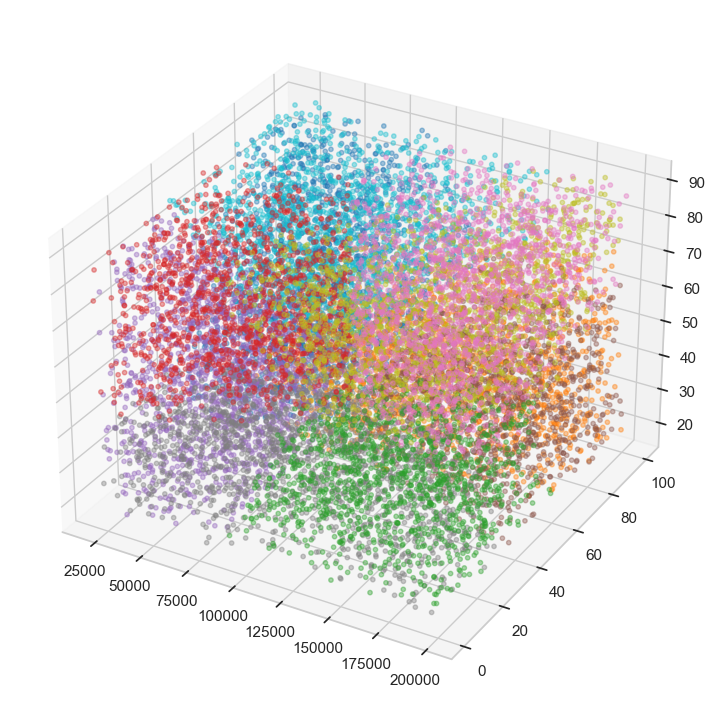

In [6]:
palette = sns.color_palette('tab10', OPTIMAL_K)

fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

for c in range(OPTIMAL_K):
    mask = cluster_labels == c
    ax.scatter(
        df.loc[mask, 'Annual Income'],
        df.loc[mask, 'Spending Score'],
        df.loc[mask, 'Age'],
        color=palette[c], label=f'Cluster {c}',
        alpha=0.4, s=10
    )

# Plot centroids (inverse transform back to original scale)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df   = pd.DataFrame(centroids_orig, columns=df_clean.columns)
ax.scatter(
    centroids_df['Annual Income'],
    centroids_df['Spending Score'],
    centroids_df['Age'],
    marker='X', s=300, c='black', zorder=10, label='Centroids'
)

ax.set_xlabel('Annual Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.set_title(f'K-Means 3D Cluster View (K={OPTIMAL_K})\n→ Each colour = one customer segment', fontweight='bold')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('data/kmeans_3d.png', bbox_inches='tight')
plt.show()
print('📊 Interpretation:')
print('   → Each colour represents one customer segment.')
print('   → Black X markers = cluster centroids (centre of each group).')
print('   → Clusters that are well-separated = good clustering quality.')

---
## Step 6: Cluster Profile Analysis

### 📌 What does each cluster represent?
After clustering, we look at the average values of each cluster to understand WHO is in each group.

In [7]:
profile = df.groupby('Cluster')[['Age','Annual Income','Spending Score']].mean().round(1)
profile['Count']      = df.groupby('Cluster')['Age'].count()
profile['% of Total'] = (profile['Count'] / len(df) * 100).round(1)
print('=== Cluster Profiles (Mean Values) ===')
print(profile)
print()
print('Assign labels based on what you see above:')
print('  → High Income + High Spending Score = VIP / Premium customers')
print('  → Low Income  + High Spending Score = Impulsive buyers')
print('  → High Income + Low  Spending Score = Conservative spenders')
print('  → Low Income  + Low  Spending Score = Budget-conscious customers')
print('  → Medium Income + Medium Score      = Average / Regular customers')

=== Cluster Profiles (Mean Values) ===
          Age  Annual Income  Spending Score  Count  % of Total
Cluster                                                        
0        53.1        60114.4            75.6   1664        11.0
1        37.0       128290.3            78.6   1563        10.4
2        35.7       152098.0            25.7   1163         7.7
3        72.3        70853.9            25.9   1309         8.7
4        49.7        57243.9            28.0   1704        11.3
5        35.5       151006.7            74.3   1273         8.4
6        73.5       156923.3            53.9   1724        11.4
7        35.1       108772.3            23.7   1625        10.8
8        74.7       152725.1            42.6   1642        10.9
9        69.7        68545.8            75.6   1412         9.4

Assign labels based on what you see above:
  → High Income + High Spending Score = VIP / Premium customers
  → Low Income  + High Spending Score = Impulsive buyers
  → High Income + Low  Spend

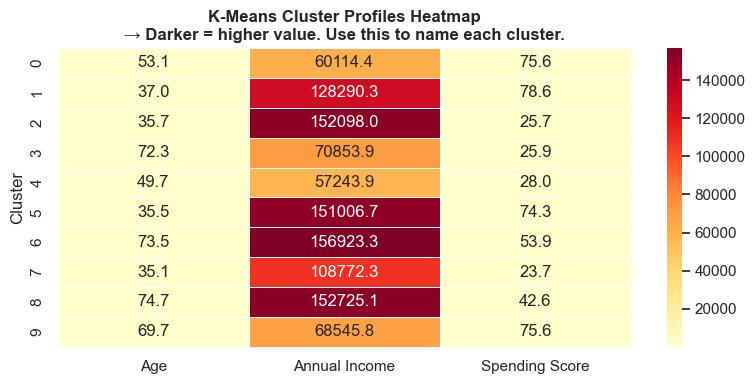

📊 How to read this heatmap:
   → Each row = one cluster
   → Each column = one feature
   → Darker colour = higher average value for that feature
   → Use this to describe what type of customer is in each cluster


In [8]:
# Heatmap of cluster profiles
heatmap_data = df.groupby('Cluster')[['Age','Annual Income','Spending Score']].mean()

plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('K-Means Cluster Profiles Heatmap\n→ Darker = higher value. Use this to name each cluster.',
          fontweight='bold')
plt.tight_layout()
plt.savefig('data/kmeans_heatmap.png', bbox_inches='tight')
plt.show()
print('📊 How to read this heatmap:')
print('   → Each row = one cluster')
print('   → Each column = one feature')
print('   → Darker colour = higher average value for that feature')
print('   → Use this to describe what type of customer is in each cluster')

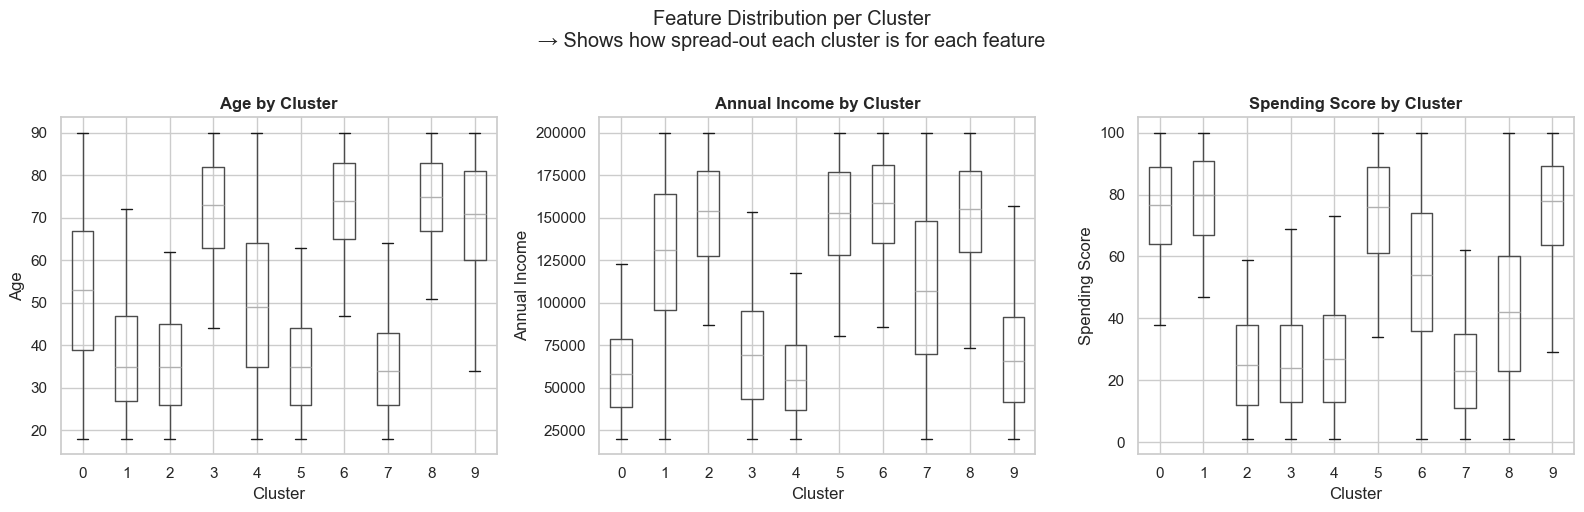

In [9]:
# Box plots showing feature distribution within each cluster
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
features  = ['Age', 'Annual Income', 'Spending Score']

for i, feat in enumerate(features):
    df.boxplot(column=feat, by='Cluster', ax=axes[i])
    axes[i].set_title(f'{feat} by Cluster', fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(feat)

plt.suptitle('Feature Distribution per Cluster\n→ Shows how spread-out each cluster is for each feature', y=1.02)
plt.tight_layout()
plt.savefig('data/kmeans_boxplots.png', bbox_inches='tight')
plt.show()

---
## Step 7: V-Measure Score

### 📌 What is V-Measure?
V-Measure combines two scores:
- **Homogeneity**: Are all members of a cluster from the same true group?
- **Completeness**: Are all members of a true group in the same cluster?

For unsupervised learning (no true labels), we use one algorithm's labels
as a 'reference' to compare against another algorithm.
This tells us how consistent the clustering is.

We save these labels and compute V-Measure in the comparison notebook.

In [10]:
# Save labels for V-Measure comparison in comparison notebook
print('V-Measure will be computed in comparison_all_methods.ipynb')
print('It compares how similar K-Means results are to MeanShift and DBSCAN.')
print('Score closer to 1.0 = two algorithms agree on the groupings.')
print()
print('✅ K-Means labels saved for comparison.')

V-Measure will be computed in comparison_all_methods.ipynb
It compares how similar K-Means results are to MeanShift and DBSCAN.
Score closer to 1.0 = two algorithms agree on the groupings.

✅ K-Means labels saved for comparison.


---
## Step 8: Save Model with Joblib

### 📌 Why save the model?
Just like the tutor's example saved `linear_regression_model.joblib`,
we save our trained K-Means model so it can be loaded by the Streamlit UI
without needing to retrain every time.

In [11]:
dump(kmeans, 'data/kmeans_model.joblib')
print('✅ Model saved: kmeans_model.joblib')
print(f'   Algorithm  : K-Means')
print(f'   K clusters : {OPTIMAL_K}')
print(f'   Trained on : {len(df_clean):,} customers')

✅ Model saved: kmeans_model.joblib
   Algorithm  : K-Means
   K clusters : 10
   Trained on : 15,079 customers


---
## Step 9: Predict New Customer Segment

### 📌 How prediction works for clustering:
1. User enters their details (Age, Gender, Income, Spending Score)
2. We scale the input the same way as training data
3. K-Means finds the nearest cluster centre
4. We tell the user which customer segment they belong to

This is equivalent to the tutor's house price prediction, but instead of a price, we output a segment label.

In [12]:
# Load model
model = load('data/kmeans_model.joblib')

# ── UPDATE THESE LABELS based on your cluster profiles above ──
# Look at Step 6 heatmap and assign meaningful names
cluster_names = {
    0: 'Budget-Conscious Customers',
    1: 'VIP / High Spenders',
    2: 'Average Customers',
    3: 'Impulsive Buyers',
    4: 'Conservative Spenders',
}  # Adjust based on your actual K and profiles!

print('=== Enter New Customer Details ===')
input_age            = int(input('Enter Age              : '))
input_gender         = input('Enter Gender (Male/Female): ').strip().capitalize()
input_annual_income  = float(input('Enter Annual Income    : '))
input_spending_score = float(input('Enter Spending Score (1-100): '))

gender_encoded = 0 if input_gender == 'Female' else 1

new_customer        = np.array([[input_age, gender_encoded, input_annual_income, input_spending_score]])
new_customer_scaled = scaler.transform(new_customer)
predicted_cluster   = model.predict(new_customer_scaled)[0]

print()
print('=' * 45)
print('         PREDICTION RESULT')
print('=' * 45)
print(f'  Predicted Cluster : {predicted_cluster}')
print(f'  Segment Name      : {cluster_names.get(predicted_cluster, "Segment " + str(predicted_cluster))}')
cluster_avg = df[df['Cluster'] == predicted_cluster][['Age','Annual Income','Spending Score']].mean()
print(f'  Cluster Avg Age   : {cluster_avg["Age"]:.0f}')
print(f'  Cluster Avg Income: {cluster_avg["Annual Income"]:,.0f}')
print(f'  Cluster Avg Score : {cluster_avg["Spending Score"]:.0f}')
print('=' * 45)

=== Enter New Customer Details ===

         PREDICTION RESULT
  Predicted Cluster : 7
  Segment Name      : Segment 7
  Cluster Avg Age   : 35
  Cluster Avg Income: 108,772
  Cluster Avg Score : 24


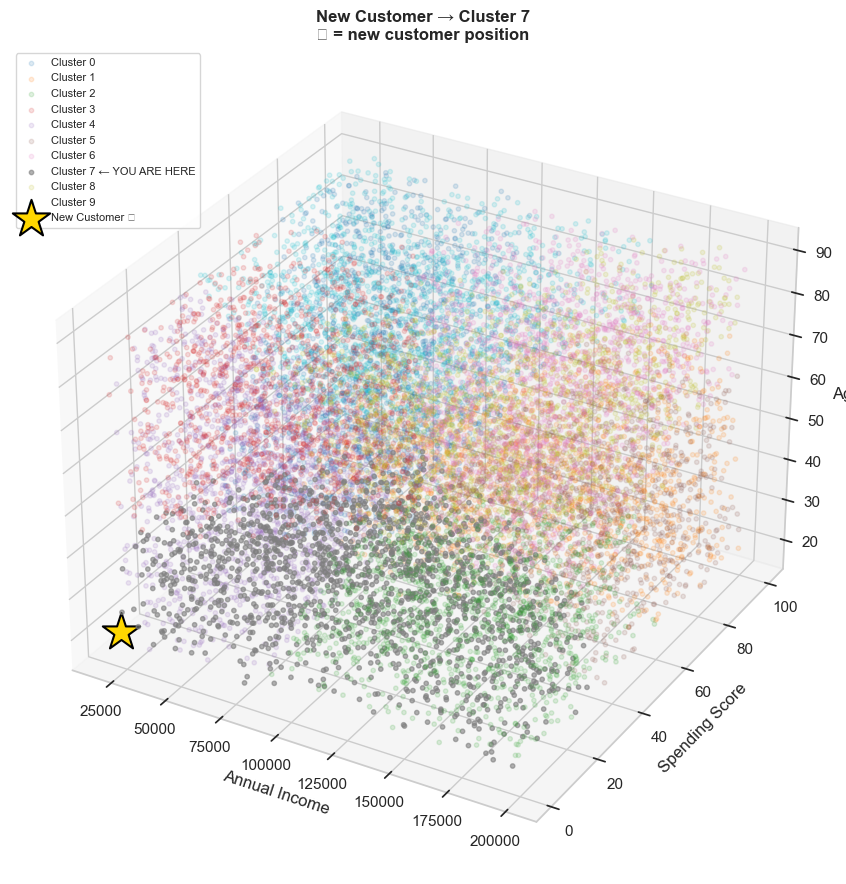

📊 The gold star shows where the new customer falls.
   Their highlighted cluster is Cluster 7.


In [13]:
# Visualise the new customer in the 3D cluster plot
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

for c in range(OPTIMAL_K):
    mask  = cluster_labels == c
    alpha = 0.6 if c == predicted_cluster else 0.15
    lbl   = f'Cluster {c} ← YOU ARE HERE' if c == predicted_cluster else f'Cluster {c}'
    ax.scatter(
        df.loc[mask, 'Annual Income'],
        df.loc[mask, 'Spending Score'],
        df.loc[mask, 'Age'],
        color=palette[c], label=lbl, alpha=alpha, s=10
    )

# Plot the new customer as a star
ax.scatter(
    [input_annual_income], [input_spending_score], [input_age],
    marker='*', s=800, c='gold', edgecolors='black', linewidths=1.5,
    zorder=10, label='New Customer ⭐'
)

ax.set_xlabel('Annual Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.set_title(f'New Customer → Cluster {predicted_cluster}\n⭐ = new customer position', fontweight='bold')
plt.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('data/kmeans_prediction.png', bbox_inches='tight')
plt.show()
print(f'📊 The gold star shows where the new customer falls.')
print(f'   Their highlighted cluster is Cluster {predicted_cluster}.')